# Level 1 — Scientific Problem Framing and Python Foundation
**ICS 2207 Scientific Computing | HydroSense-Kenya**

---

## 1. Scientific Problem Statement

Smallholder farms across Kenya face a growing water-management crisis. Erratic rainfall patterns linked to climate variability, combined with the absence of affordable decision-support tools, mean that farmers either over-irrigate (wasting water and energy) or under-irrigate (exposing crops to stress and yield loss).

**The HydroSense-Kenya system** addresses this problem by building a Python-based scientific computing pipeline that:

1. Ingests daily weather and soil-sensor data from three crop zones (Zone_A: tomato, Zone_B: kale, Zone_C: maize).
2. Estimates daily evapotranspiration (ET) from meteorological variables.
3. Simulates soil-water balance to track moisture dynamics.
4. Detects water stress events and quantifies cumulative deficits.
5. Recommends optimized irrigation schedules that minimize water use without causing moisture stress.

**Central scientific question:**  
*Given weather and soil-sensor data, how can we model water availability, estimate water deficit, simulate future soil moisture, and recommend an efficient irrigation plan that minimizes water use without exposing crops to moisture stress?*

**Scope:** Kenyan demonstration farm.  


## 2. Load and inspect the datasets.

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

weather = pd.read_csv("../data/raw/weather_daily.csv", na_values=["NA", ""], parse_dates=["date"]) 
soil = pd.read_csv("../data/raw/soil_sensor_data.csv", na_values=["NA", ""], parse_dates=["timestamp"]) 
params = pd.read_csv("../data/raw/crop_zone_parameters.csv", na_values=["NA", ""]) 

print("WEATHER DATASET")
print(weather.info())
print()
print("SOIL  SENSOR DATASET")
print(soil.info())
print()
print("PARAMS DATASET")
print(params.info())

WEATHER DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            30 non-null     datetime64[ns]
 1   rainfall_mm     29 non-null     float64       
 2   temperature_c   30 non-null     float64       
 3   humidity_pct    29 non-null     float64       
 4   wind_speed_mps  30 non-null     float64       
 5   solar_index     30 non-null     float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 1.5 KB
None

SOIL  SENSOR DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   timestamp          90 non-null     datetime64[ns]
 1   zone_id            90 non-null     object        
 2   soil_moisture_pct  89 non-null     float64       
 3 

## 3. Data Dictionary for all the variables in the hydroSense-Kenya datasets.

In [3]:
data_dictionary = {
    # weather_daily.csv 
    "date":              {"type": "datetime", "unit": "YYYY-MM-DD",  "source": "weather_daily",      "description": "Calendar date of observation"},
    "rainfall_mm":       {"type": "float",    "unit": "mm/day",      "source": "weather_daily",      "description": "Daily accumulated rainfall; NA = sensor fault"},
    "temperature_c":     {"type": "float",    "unit": "°C",          "source": "weather_daily",      "description": "Daily mean air temperature; outlier at 45.8°C on 2026-03-14"},
    "humidity_pct":      {"type": "float",    "unit": "%",           "source": "weather_daily",      "description": "Daily mean relative humidity; NA on 2026-03-21"},
    "wind_speed_mps":    {"type": "float",    "unit": "m/s",         "source": "weather_daily",      "description": "Daily mean wind speed"},
    "solar_index":       {"type": "float",    "unit": "dimensionless","source": "weather_daily",     "description": "Normalized solar intensity index (0–1)"},

    #soil_sensor_data.csv
    "timestamp":         {"type": "datetime", "unit": "YYYY-MM-DD HH:MM", "source": "soil_sensor", "description": "Daily noon sensor reading timestamp"},
    "zone_id":           {"type": "str",      "unit": "—",           "source": "soil_sensor",        "description": "Farm zone identifier: Zone_A, Zone_B, or Zone_C"},
    "soil_moisture_pct": {"type": "float",    "unit": "%vol",        "source": "soil_sensor",        "description": "Volumetric soil moisture; NA on 2026-03-06 Zone_B; anomaly on 2026-03-25 Zone_B"},
    "tank_level_liters": {"type": "float",    "unit": "litres",      "source": "soil_sensor",        "description": "Water tank level; anomalous spike to 9900 L on 2026-03-14 Zone_C"},
    "pump_flow_lpm":     {"type": "float",    "unit": "L/min",       "source": "soil_sensor",        "description": "Pump flow rate; 0 on 2026-03-21 Zone_B (sensor CHECK)"},
    "pump_power_watts":  {"type": "float",    "unit": "W",           "source": "soil_sensor",        "description": "Pump power consumption"},
    "sensor_status":     {"type": "str",      "unit": "—",           "source": "soil_sensor",        "description": "OK = nominal; CHECK = potential sensor fault"},

    #crop_zone_parameters.csv 
    "zone_id_params": {"type": "str", "unit": "—", "source": "crop_params", "description": "Zone identifier for parameter mapping"},
    "crop_type":         {"type": "str",      "unit": "—",           "source": "crop_params",        "description": "Crop grown in this zone"},
    "area_m2":           {"type": "float",    "unit": "m²",          "source": "crop_params",        "description": "Zone irrigated area"},
    "min_moisture_pct":  {"type": "float",    "unit": "%vol",        "source": "crop_params",        "description": "Minimum soil moisture before stress occurs"},
    "target_moisture_pct":{"type": "float",   "unit": "%vol",        "source": "crop_params",        "description": "Irrigation refill target moisture"},
    "field_capacity_pct":{"type": "float",    "unit": "%vol",        "source": "crop_params",        "description": "Maximum soil water-holding capacity"},
    "drainage_coefficient":{"type": "float",  "unit": "day⁻¹",       "source": "crop_params",        "description": "Fraction of excess water drained per day (0–1)"},
    
    # derived
    "ET_mm":             {"type": "float",    "unit": "mm/day",      "source": "derived",            "description": "Estimated evapotranspiration from simplified empirical formula"},
    "water_deficit_mm":  {"type": "float",    "unit": "mm/day",      "source": "derived",            "description": "max(0, ET - Rainfall): daily water deficit"},
    "S_next":            {"type": "float",    "unit": "%vol",        "source": "derived",            "description": "Soil moisture at next time step from water balance"},
}

print(f"{'Variable':<25} {'Unit':<18} {'Source':<15} {'Description'}")
for var, meta in data_dictionary.items():
    print(f"{var:<25} {meta['unit']:<18} {meta['source']:<15} {meta['description']}")


Variable                  Unit               Source          Description
date                      YYYY-MM-DD         weather_daily   Calendar date of observation
rainfall_mm               mm/day             weather_daily   Daily accumulated rainfall; NA = sensor fault
temperature_c             °C                 weather_daily   Daily mean air temperature; outlier at 45.8°C on 2026-03-14
humidity_pct              %                  weather_daily   Daily mean relative humidity; NA on 2026-03-21
wind_speed_mps            m/s                weather_daily   Daily mean wind speed
solar_index               dimensionless      weather_daily   Normalized solar intensity index (0–1)
timestamp                 YYYY-MM-DD HH:MM   soil_sensor     Daily noon sensor reading timestamp
zone_id                   —                  soil_sensor     Farm zone identifier: Zone_A, Zone_B, or Zone_C
soil_moisture_pct         %vol               soil_sensor     Volumetric soil moisture; NA on 2026-03-06 Zone_B; 

## 4. Core scientific functions for evapotranspiration and water balance.

In [4]:

# 3a. Evapotranspiration — scalar and vectorised


def compute_et(T: float, W: float, Solar: float, H: float) -> float:
    """
    Simplified daily ET estimate (mm/day).
    ET = max(0, 0.12*T + 0.35*W + 2.4*Solar - 0.025*H)
    
    Parameters: T=temperature(°C), W=wind(m/s), Solar=solar index(0-1), H=humidity(%)
    """
    return float(np.maximum(0.0, 0.12 * T + 0.35 * W + 2.4 * Solar - 0.025 * H))


def compute_et_vectorised(T, W, Solar, H):
    """Vectorised ET for NumPy arrays (same formula, no loops)."""
    return np.maximum(0.0, 0.12 * T + 0.35 * W + 2.4 * Solar - 0.025 * H)


# 3b. Water balance step

def water_balance_step(S_t, R_t, I_t, ET_t, field_capacity, drainage_coeff):
    """
    One discrete water-balance step:
      S(t+1) = S(t) + R(t) + I(t) - ET(t) - D(t)
    D(t) = drainage_coeff * max(0, S_raw - field_capacity)
    
    Returns (S_next, D_t)
    """
    S_raw = S_t + R_t + I_t - ET_t
    excess = max(0.0, S_raw - field_capacity)
    D_t = drainage_coeff * excess
    S_next = max(0.0, S_raw - D_t)
    return S_next, D_t


def run_water_balance(S0, rainfall, irrigation, et, field_capacity, drainage_coeff):
    """Run water balance over N days. Returns moisture array (N+1) and drainage array (N)."""
    N = len(rainfall)
    moisture  = np.zeros(N + 1)
    drainage  = np.zeros(N)
    moisture[0] = S0
    for t in range(N):
        moisture[t+1], drainage[t] = water_balance_step(
            moisture[t], rainfall[t], irrigation[t], et[t], field_capacity, drainage_coeff)
    return moisture, drainage


## 5. Initial Scientific Visualizations

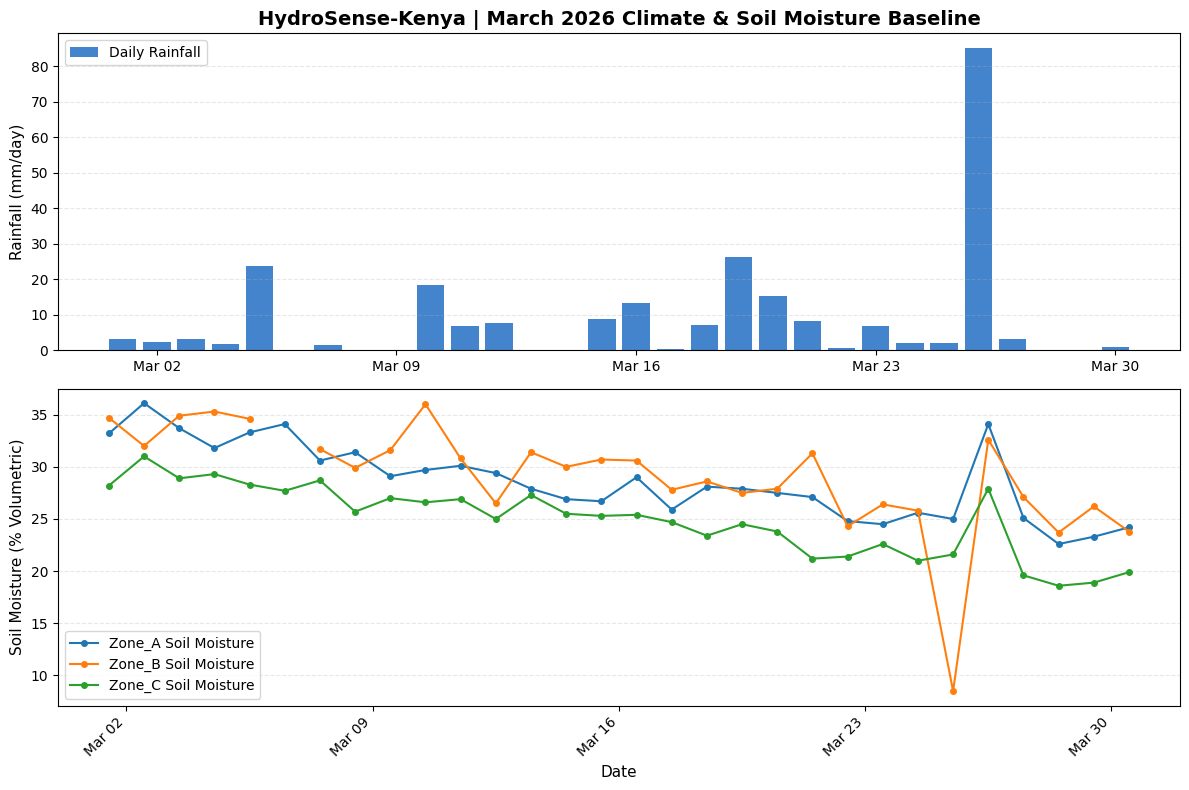

In [5]:
# Set up a 2-panel figure sharing a uniform timeline appearance
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

# Panel 1: Baseline Daily Rainfall
# We display this as a bar chart to represent daily discrete accumulation
ax1.bar(
    weather["date"],
    weather["rainfall_mm"],
    color="#1565C0",
    alpha=0.8,
    label="Daily Rainfall",
)
ax1.set_title(
    "HydroSense-Kenya | March 2026 Climate & Soil Moisture Baseline",
    fontsize=14,
    fontweight="bold",
)
ax1.set_ylabel("Rainfall (mm/day)", fontsize=11)
ax1.grid(axis="y", linestyle="--", alpha=0.3)
ax1.legend(loc="upper left")

ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))

# Panel 2: Baseline Soil Moisture Trends by Zone
# We isolate and plot each zone uniquely to track ground-level feedback
# Note: The data dictionary confirms zone labels match 'Zone A', 'Zone B', 'Zone C'
for zone in ["Zone_A", "Zone_B", "Zone_C"]:
    zone_data = soil[soil["zone_id"] == zone]
    ax2.plot(
        zone_data["timestamp"],
        zone_data["soil_moisture_pct"],
        marker="o",
        markersize=4,
        linewidth=1.5,
        label=f"{zone} Soil Moisture",
    )

ax2.set_xlabel("Date", fontsize=11)
ax2.set_ylabel("Soil Moisture (% Volumetric)", fontsize=11)
ax2.grid(axis="y", linestyle="--", alpha=0.3)
ax2.legend(loc="lower left")

# Configure date formatting and rotation for the lower panel
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha="right")

# 3. Final layout configuration
plt.tight_layout()
plt.show()


## 6. Assumptions and Limitations

### Assumptions
1. **ET formula is simplified.** The simplified empirical formula `ET = max(0, 0.12T + 0.35W + 2.4·Solar − 0.025H)` captures the main drivers. However, it assumes that wind, temperature, solar intensity, and humidity interact in a fixed, linear fashion without factoring in real-world adjustments like aerodynamic resistance or crop-specific growth coefficients.
2. **Rainfall contribution is 1:1.** We assume all rainfall enters the soil balance without accounting for runoff or canopy interception.
3. **Drainage is linear.** Drainage beyond field capacity is modelled as a linear fraction (`D = k × excess`). In reality, drainage is nonlinear.
4. **Uniform spatial distribution.** Each zone is treated as spatially homogeneous; no within-zone variability is modelled.
5. **Daily time step.** The model operates at daily resolution; sub-daily dynamics (morning dew, afternoon storms) are ignored.
6. **Sensors are representative.** Noon soil readings are assumed to represent daily averages.

### Limitations
- Missing sensor readings require imputation; imputed values introduce uncertainty.
-Lack of Crop Growth Stage Integration; The initial water balance model treats crop water demand identically regardless of age. In reality, a juvenile tomato or maize plant consumes far less water than a mature crop nearing harvest
- The 30-day period may not represent seasonal behaviour.
- The optimized schedule assumes perfect ET and rainfall forecasts; in practice, forecasts carry uncertainty.
- Pump energy costs are not fully integrated into the optimization objective.
